## Euro 2024 — event-level tactics (Germany)

Same **Open Data** GitHub JSON as notebook 01. Here we turn **events** into small, testable metrics:

1. **Pressing** — `Pressure` events for Germany; `counterpress` where the column exists.
2. **Attack** — `Shot` volume and **StatsBomb xG** (`shot.statsbomb_xg`).
3. **Compactness proxy** — **median pitch `x` of Germany clearances, blocks, and interceptions**. Lower values often mean actions closer to the goal Germany is defending (deeper block) in this dataset’s coordinates — still a **rough** proxy, not a full defensive shape model.

Run from the **repository root** (or ensure `germany_euro2024_match_ids.csv` from notebook 01 is discoverable).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests

OPEN_DATA = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"
EURO_2024_COMPETITION_ID = 55
EURO_2024_SEASON_ID = 282
GERMANY = "Germany"

ROOT = Path.cwd()
ids_path = ROOT / "statsbomb" / "germany_euro2024_match_ids.csv"
if ids_path.exists():
    match_ids = pd.read_csv(ids_path)["match_id"].astype(int).tolist()
else:
    url = f"{OPEN_DATA}/matches/{EURO_2024_COMPETITION_ID}/{EURO_2024_SEASON_ID}.json"
    r = requests.get(url)
    r.raise_for_status()
    m = pd.json_normalize(r.json())
    mask = (m["home_team.home_team_name"] == GERMANY) | (
        m["away_team.away_team_name"] == GERMANY
    )
    match_ids = m.loc[mask, "match_id"].astype(int).tolist()

match_ids

[3942226, 3940983, 3930168, 3930176, 3930158]

### Summarise one match
We parse `location` as `[x, y]` lists from the JSON.

In [2]:
def loc_x(loc):
    if isinstance(loc, (list, tuple)) and len(loc) >= 1:
        return float(loc[0])
    return float("nan")


def load_events(match_id: int) -> pd.DataFrame:
    url = f"{OPEN_DATA}/events/{match_id}.json"
    r = requests.get(url)
    r.raise_for_status()
    return pd.json_normalize(r.json())


def summarise_match(match_id: int) -> dict:
    e = load_events(match_id)
    is_ger = e["team.name"] == GERMANY

    pr = e[(e["type.name"] == "Pressure") & is_ger]
    counter = 0
    if "counterpress" in pr.columns:
        counter = int((pr["counterpress"] == True).sum())

    sh = e[(e["type.name"] == "Shot") & is_ger]
    xg_col = "shot.statsbomb_xg"
    xg = float(sh[xg_col].sum()) if xg_col in sh.columns else float("nan")

    def_types = {"Clearance", "Block", "Interception"}
    defs = e[(e["type.name"].isin(def_types)) & is_ger]
    xs = defs["location"].map(loc_x)
    med_x_def = float(xs.median()) if not xs.empty else float("nan")

    return {
        "match_id": match_id,
        "pressures": len(pr),
        "counterpress_events": counter,
        "shots": len(sh),
        "xg": xg,
        "compactness_median_x_def_actions": med_x_def,
    }


summarise_match(match_ids[0])

{'match_id': 3942226,
 'pressures': 183,
 'counterpress_events': 33,
 'shots': 23,
 'xg': 1.6290745859999998,
 'compactness_median_x_def_actions': 17.55}

In [3]:
mr = requests.get(
    f"{OPEN_DATA}/matches/{EURO_2024_COMPETITION_ID}/{EURO_2024_SEASON_ID}.json"
)
mr.raise_for_status()
all_matches = pd.json_normalize(mr.json())
meta = all_matches[all_matches["match_id"].isin(match_ids)][
    [
        "match_id",
        "match_date",
        "home_team.home_team_name",
        "away_team.away_team_name",
        "home_score",
        "away_score",
    ]
]

rows = [summarise_match(mid) for mid in match_ids]
summary = pd.DataFrame(rows).merge(meta, on="match_id").sort_values("match_date")
summary["result"] = (
    summary["home_score"].astype(int).astype(str)
    + ":"
    + summary["away_score"].astype(int).astype(str)
)
summary = summary.drop(columns=["home_score", "away_score"])
summary

,match_id,pressures,counterpress_events,shots,xg,compactness_median_x_def_actions,match_date,home_team.home_team_name,away_team.away_team_name,result
4,3930158,121,26,20,1.844634,47.20,2024-06-14,Germany,Scotland,5:1
2,3930168,140,31,19,1.483693,11.50,2024-06-19,Germany,Hungary,2:0
3,3930176,147,45,18,1.541678,50.60,2024-06-23,Switzerland,Germany,1:1
1,3940983,116,33,15,2.226621,15.20,2024-06-29,Germany,Denmark,2:0
0,3942226,183,33,23,1.629075,17.55,2024-07-05,Spain,Germany,2:1


### Quick charts
Pressing volume and xG per match (small sample — interpret carefully).

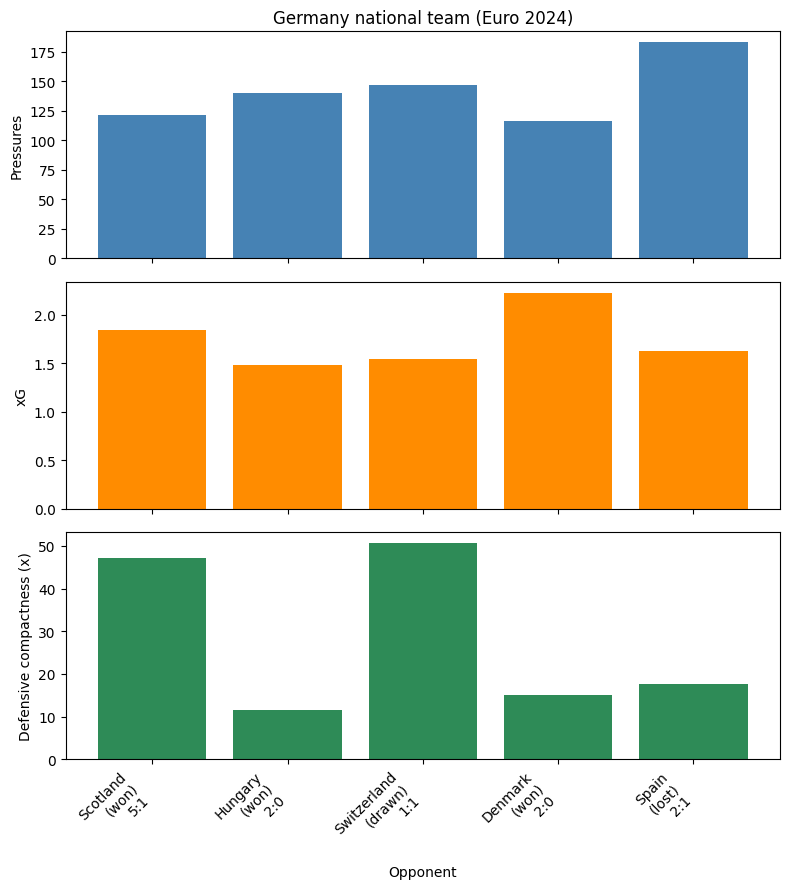

In [4]:
def get_label(r):
    is_home = r["home_team.home_team_name"] == GERMANY
    opp = r["away_team.away_team_name"] if is_home else r["home_team.home_team_name"]
    score_str = r["result"]
    scores = score_str.split(":")
    home_score = int(scores[0])
    away_score = int(scores[1])
    ger_score = home_score if is_home else away_score
    opp_score = away_score if is_home else home_score
    if ger_score > opp_score:
        res = "won"
    elif ger_score < opp_score:
        res = "lost"
    else:
        res = "drawn"
    return f"{opp}\n({res})\n{score_str}"

opponent = summary.apply(get_label, axis=1)
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
axes[0].bar(opponent, summary["pressures"], color="steelblue")
axes[0].set_ylabel("Pressures")
axes[0].set_title("Germany national team (Euro 2024)")
axes[1].bar(opponent, summary["xg"], color="darkorange")
axes[1].set_ylabel("xG")
axes[2].bar(opponent, summary["compactness_median_x_def_actions"], color="seagreen")
axes[2].set_ylabel("Defensive compactness (x)")
axes[2].set_xlabel("Opponent")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
